# Domácí úkol

## Instrukce k odevzdávání
- Odevzdává se vyplněný notebook `DU3.ipynb` v repozitáři na GitHubu.
- Repozitář pro odevzdávání je `vvp-DU` a musí být veřejný na GitHubu.
- Základní část úkolu je hodnocena za 10 bodů.
- Část „Bonusové úkoly“ není součástí základního hodnocení (10 b) a je hodnocena za +2 body navíc (do maxima 50 b za domácí úkoly celkem).
- Vypracovaný úkol je potřeba pushnout do GitHubu; doporučuje se ověřit, že je pushnutý aktuální stav.
- Kontrola probíhá vždy den (nejpozději v 6:00 tam úkol musí být) před následujícím cvičením/tutoriálem; hodnotí se aktuální stav repozitáře.
- Nemažte ze souboru části se zadáním.
- Před termínem odevzdání restartujte kernel a ověřte, že je notebook plně spustitelný.
- Odevzdaný notebook nechte včetně výstupů.
- Nekopírujte řešení od kolegů; při nejasnostech se ptejte na princip, ne na hotové řešení.
- AI nástroje (Copilot, ChatGPT, Bard apod.) můžete používat, ale musíte rozumět odevzdanému řešení; slepý copy-paste bez porozumění (tedy neschopnosti odpovědět na dotaz k vašemu odevzdanému řešení) může vést k hodnocení 0 b.

## Část 1: Číselná spirála

Vytvořte čtvercovou matici o lichém počtu řádků a sloupců, která bude obsahovat čísla od 1 do $n^2$ tak, aby číslo 1 bylo uprostřed matice a číselná řada postupně narůstala po spirále proti směru hodinových ručiček.
- udělejte to pomocí NumPy přiřazování sliců do pole,
- výstup musí být stejný jako u primitivní funkce `integer_spiral` níže,
- vyplňujte matici po „kruzích“ okolo středu,
    - každý kruh je tvořen 4 částmi (hrana bez jednoho rohu),
    - využijte možnosti přiřazování sliců do pole a indexace s krokem `-1`,
    - použijte `np.arange` pro vytvoření řady čísel, kterou budete ukládat do hrany,
- pomozte si také okrajem z nul, který nakonec oříznete.

**Výsledná funkce bude mít tedy pouze jednu smyčku, ve které do pole vstoupíte pouze 4x (jednou za každou hranu).**

**Na závěr porovnejte rychlost vaší funkce s `integer_spiral` níže pomocí `%timeit` a různých velikostí výsledných matic (např. 101, 1001, 10001).**


In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [38]:
# naplnění matice spirálou čísel
def integer_spiral(n):
    # abychom nemuseli řešit okraj = kontrolovat jestli jsme mimo matici
    # vytvoříme matici o velikosti n+2 x n+2
    # a vyplníme pouze středovou část
    A = np.zeros((n + 2, n + 2))

    pos_row = n//2 + 1  # počáteční pozice: střed matice
    pos_col = n//2 + 1

    i = 1  # číslo, které se bude vkládat do matice

    A[pos_row, pos_col] = i  # vložíme číslo do středu matice
    i += 1
    pos_col += 1  # posuneme se na první volné místo

    while i <= n**2:  # dokud nejsme na konci matice
        A[pos_row, pos_col] = i  # vložíme číslo na aktuální pozici
        i += 1  # zvýšíme číslo, které se má vložit
        if A[pos_row - 1, pos_col] != 0 and A[pos_row, pos_col + 1] == 0:
            pos_col += 1  # posuneme se doprava
        elif A[pos_row, pos_col - 1] != 0:
            pos_row -= 1  # posuneme se nahoru
        elif A[pos_row + 1, pos_col] != 0:
            pos_col -= 1  # posuneme se doleva
        else:
            pos_row += 1  # posuneme se dolů

    return A[1:-1, 1:-1]  # ořízneme nulový okraj


In [39]:
A = integer_spiral(7)
print(A)

[[37. 36. 35. 34. 33. 32. 31.]
 [38. 17. 16. 15. 14. 13. 30.]
 [39. 18.  5.  4.  3. 12. 29.]
 [40. 19.  6.  1.  2. 11. 28.]
 [41. 20.  7.  8.  9. 10. 27.]
 [42. 21. 22. 23. 24. 25. 26.]
 [43. 44. 45. 46. 47. 48. 49.]]


In [ ]:
def integer_spiral_slicing(n):
    #TODO naimplementujte viz zadání
    rada = np.arange(1, n*n + 1, 1)
    A = np.zeros((n + 2, n + 2))
    
    stred = n//2 +1
    A[stred, stred] = rada[0]
    pocet_kruhu = n//2
        
    start = 1    
    for i in range(0, pocet_kruhu):
        A[pocet_kruhu + 1 + i : pocet_kruhu - 1 - i : -1, pocet_kruhu + 2 + i] = rada[start: start + 2*(i + 1)]
        A[pocet_kruhu - i, pocet_kruhu + 1 + i: pocet_kruhu - 1 - i : -1] = rada[start + 2*(i + 1): start + 4*(i + 1)]
        A[pocet_kruhu + 1 - i : pocet_kruhu + 3 + i : +1, pocet_kruhu - i] = rada[start + 4*(i + 1) : start + 6*(i + 1)]
        A[pocet_kruhu + 2 + i, pocet_kruhu + 1 - i : pocet_kruhu + 3 + i: +1] = rada[start + 6*(i + 1) : start + 8*(i + 1)]
        start = start + 8*(i + 1)
        
    return A[1:-1, 1:-1]

print(integer_spiral_slicing(11))

[[101. 100.  99.  98.  97.  96.  95.  94.  93.  92.  91.]
 [102.  65.  64.  63.  62.  61.  60.  59.  58.  57.  90.]
 [103.  66.  37.  36.  35.  34.  33.  32.  31.  56.  89.]
 [104.  67.  38.  17.  16.  15.  14.  13.  30.  55.  88.]
 [105.  68.  39.  18.   5.   4.   3.  12.  29.  54.  87.]
 [106.  69.  40.  19.   6.   1.   2.  11.  28.  53.  86.]
 [107.  70.  41.  20.   7.   8.   9.  10.  27.  52.  85.]
 [108.  71.  42.  21.  22.  23.  24.  25.  26.  51.  84.]
 [109.  72.  43.  44.  45.  46.  47.  48.  49.  50.  83.]
 [110.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.]
 [111. 112. 113. 114. 115. 116. 117. 118. 119. 120. 121.]]


In [91]:
# TODO otestujte rychlost obou implementací
print("prvni funkce 101")
%timeit integer_spiral(101)
print("\ndruha funkce 101")
%timeit integer_spiral_slicing(101)

print("\nprvni funkce 1001")
%timeit integer_spiral(1001)
print("\ndruha funkce 1001")
%timeit integer_spiral_slicing(1001)

print("\nprvni funkce 10001")
%timeit integer_spiral(10001)
print("\ndruha funkce 10001")
%timeit integer_spiral_slicing(10001)

prvni funkce 101
4.81 ms ± 39.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

druha funkce 101
125 μs ± 1.03 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

prvni funkce 1001
487 ms ± 2.95 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

druha funkce 1001
5.34 ms ± 54.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

prvni funkce 10001
51.2 s ± 1.59 s per loop (mean ± std. dev. of 7 runs, 1 loop each)

druha funkce 10001
620 ms ± 43 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Část 2: Mandelbrotova množina
Vizualizujte Mandelbrotovu množinu na intervalu $[-2, 1] \times [-1.5, 1.5]$ pomocí `imshow`. Výsledek by měl vypadat jako na následujícím obrázku.
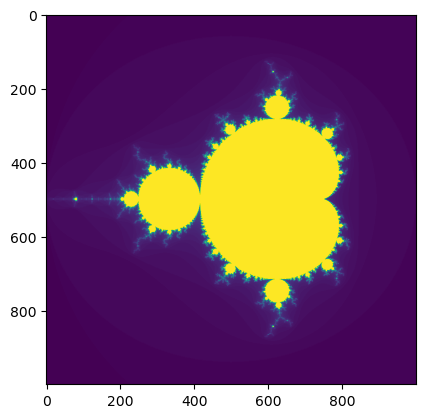

**Co je Mandelbrotova množina?**

Mandelbrotova množina je množina komplexních čísel $c$, pro které platí, že posloupnost $z_{i+1} = z_i^2 + c$ s $z_0 = 0$ nekonverguje do nekonečna (tj. $|z_i|$ zůstává omezené).

**Co tedy udělat?**
- vytvořte matici $n\times n$ komplexních čísel $c$ na intervalu $[-2, 1] \times [-1.5, 1.5]$ (pomocí `np.mgrid` nebo `np.meshgrid`),
    - využijte výhody vektorizace a toho, že NumPy umí násobit komplexní čísla,
- stanovte si počet iterací $k$, pro které budete testovat, zda posloupnost nedivergovala,
    - divergování posloupnosti poznáme tak, že $|z_i| > 2$ pro nějaké $i$,
- proveďte $k$ iterací posloupnosti $z_{i+1} = z_i^2 + c$ a zjistěte, ve které iteraci nastalo $|z_i| > 2$ (jakmile to nastane jednou, bude to platit pro všechna další $i$),
    - použijte pomocnou matici `divergence_matrix`, která bude mít stejný rozměr jako `c` a bude obsahovat počet iterací, kdy $|z_i| < 2$ pro každé $c$,
- vytvořte obrázek pomocí `imshow` z `divergence_matrix`.

In [101]:
def mandelbrot_set(x_min = -2, x_max = 1, y_min = -1.5, y_max = 1.5, n = 1000, k = 100):
    # TODO naimplementujte viz zadání
    x, y = np.linspace(x_min, x_max, n), np.linspace(y_min, y_max, n)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y

    Z = np.zeros_like(C, dtype=complex)
    divergence_matrix = np.zeros(C.shape, dtype=int)
    mask = np.ones(C.shape, dtype=bool)

    for i in range(1, k + 1):
        Z[mask] = Z[mask]**2 + C[mask]
        diverze = np.abs(Z) > 2
        nova_diverze = diverze & mask
        divergence_matrix[nova_diverze] = i
        mask &= ~diverze

    divergence_matrix[divergence_matrix == 0] = k
    
    return divergence_matrix

mandelbrot_set()

array([[1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       ...,
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2]], shape=(1000, 1000))

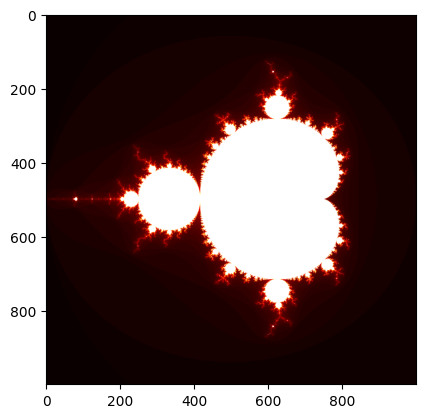

In [103]:
n = 1000
k = 100

divergence_matrix = mandelbrot_set(n=n, k=k)
plt.imshow(divergence_matrix, cmap='hot')

## Bonusové úkoly
1. Vykreslete také Juliovu množinu (viz https://en.wikipedia.org/wiki/Julia_set).
2. Použijte váš kód pro číselnou spirálu a vytvořte obrázek prvočíselné spirály (viz https://en.wikipedia.org/wiki/Ulam_spiral).